### Batch based [imp: remove df = df.head(20000)]

Visualizing Batch from 2022-02-11 08:55:00 (4 orders)


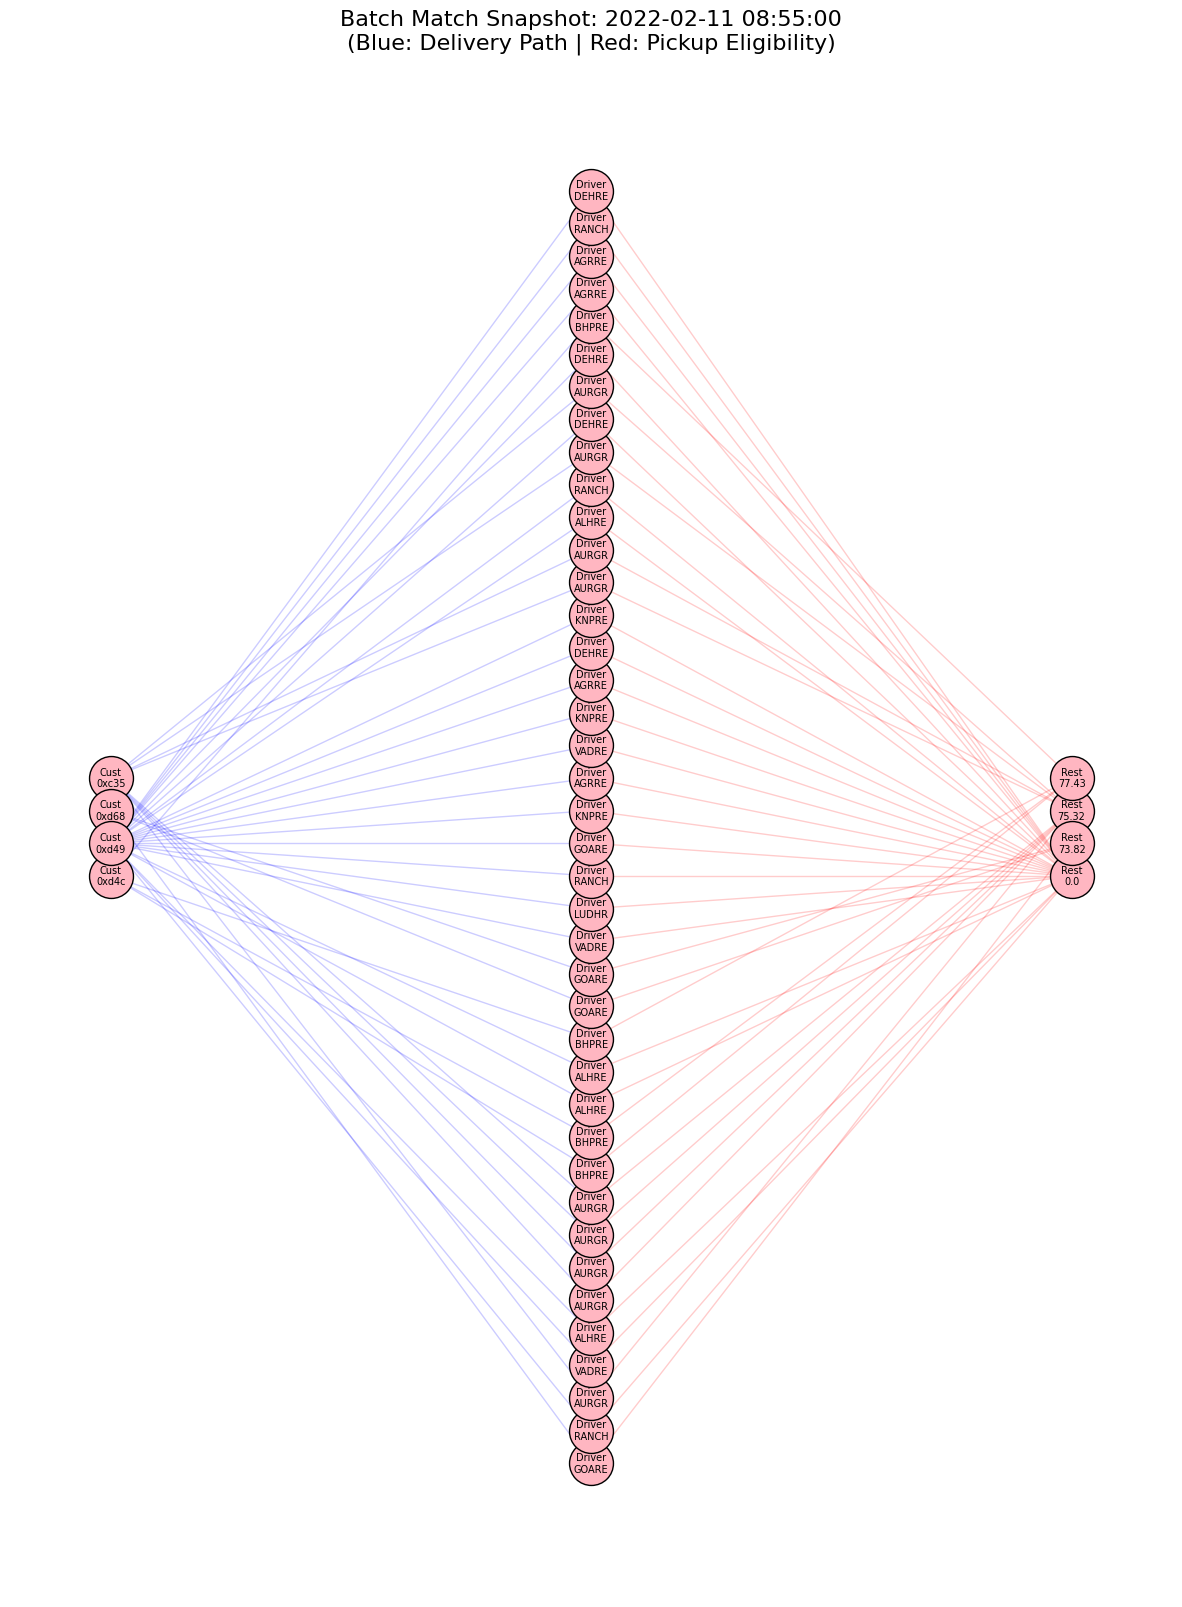

In [16]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

# --- Configuration ---
DELTA_MINUTES = 5
DISTANCE_D_KM = 5.0
BATCH_TO_PLOT = 10 # Index of the batch you want to see (0 = first batch)

# 1. Load and Clean Data (Pandas 2.0+ compatible)
df = pd.read_csv('train_with_all_distances.csv')
df = df.head(20000)  # Limit to 20k for faster processing in this example
df = df.dropna(subset=['Order_Date', 'Time_Orderd']).copy()
df['Timestamp'] = pd.to_datetime(df['Order_Date'] + ' ' + df['Time_Orderd'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['Timestamp']).sort_values('Timestamp')
df['Batch_ID'] = df['Timestamp'].dt.floor(f'{DELTA_MINUTES}min')

# 2. Extract a Single Batch
batches = list(df.groupby('Batch_ID'))
batch_time, batch_df = batches[BATCH_TO_PLOT]
print(f"Visualizing Batch from {batch_time} ({len(batch_df)} orders)")

# 3. Build the Tripartite Graph for this Batch
G_batch = nx.Graph()

# Nodes for this window
customers = [f"Cust_{row['ID']}" for _, row in batch_df.iterrows()]
restaurants = [f"Rest_{round(row['Restaurant_latitude'], 4)}_{round(row['Restaurant_longitude'], 4)}" 
               for _, row in batch_df.iterrows()]
restaurants = list(set(restaurants)) # Unique restaurants in this batch

# For drivers, we'll only show those near the restaurants in THIS batch
unique_drivers = df[['Delivery_person_ID', 'Driver_latitude', 'Driver_longitude']].drop_duplicates()
driver_coords_rad = np.radians(unique_drivers[['Driver_latitude', 'Driver_longitude']].values)

# BallTree to find drivers near the restaurants of this batch
batch_rest_coords = batch_df[['Restaurant_latitude', 'Restaurant_longitude']].drop_duplicates()
rest_coords_rad = np.radians(batch_rest_coords.values)
tree = BallTree(driver_coords_rad, metric='haversine')
indices = tree.query_radius(rest_coords_rad, r=DISTANCE_D_KM/6371.0)

involved_drivers = []
for d_idx_list in indices:
    for d_idx in d_idx_list:
        driver_id = f"Driver_{unique_drivers.iloc[d_idx]['Delivery_person_ID']}"
        involved_drivers.append(driver_id)
involved_drivers = list(set(involved_drivers))[:40] # Limit to 40 for visual clarity

# Add nodes with partitions
for c in customers: G_batch.add_node(c, partition=0)  # Left
for d in involved_drivers: G_batch.add_node(d, partition=1) # Center (Offline Hub)
for r in restaurants: G_batch.add_node(r, partition=2) # Right

# Add Edges (Constraint-based)
# E_r: Driver to Restaurant (within d)
for rest_idx, d_indices in enumerate(indices):
    r_row = batch_rest_coords.iloc[rest_idx]
    r_id = f"Rest_{round(r_row['Restaurant_latitude'], 4)}_{round(r_row['Restaurant_longitude'], 4)}"
    for d_idx in d_indices:
        d_id = f"Driver_{unique_drivers.iloc[d_idx]['Delivery_person_ID']}"
        if d_id in involved_drivers:
            G_batch.add_edge(r_id, d_id, color='red')

# E_l: Customer to Driver (Implicitly through Restaurant)
for _, row in batch_df.iterrows():
    c_id = f"Cust_{row['ID']}"
    r_id = f"Rest_{round(row['Restaurant_latitude'], 4)}_{round(row['Restaurant_longitude'], 4)}"
    if G_batch.has_node(r_id):
        for d_id in G_batch.neighbors(r_id):
            G_batch.add_edge(c_id, d_id, color='blue')

# 4. Generate Multipartite Layout (The "Pink Column" Look)
pos = nx.multipartite_layout(G_batch, subset_key="partition")

plt.figure(figsize=(15, 20))
plt.title(f"Batch Match Snapshot: {batch_time}\n(Blue: Delivery Path | Red: Pickup Eligibility)", fontsize=16)

# Draw Edges
colors = [G_batch[u][v].get('color', 'black') for u, v in G_batch.edges()]
nx.draw_networkx_edges(G_batch, pos, edge_color=colors, alpha=0.2)

# Draw Nodes (Pink Rectangles/Circles)
nx.draw_networkx_nodes(G_batch, pos, node_color='lightpink', node_size=1000, edgecolors='black')

# Clean Labels
labels = {n: n.split('_')[0] + "\n" + n.split('_')[-1][:5] for n in G_batch.nodes()}
nx.draw_networkx_labels(G_batch, pos, labels, font_size=7)

plt.axis('off')
plt.show()